# Testing state abstraction on Ott's data

Now that we have established that the bayesian hierarchical models we have devised are able to 

While we aim to collect a whole new data set for this project, we can nontheless test whether our state abstraction model of existing data. The design we aim to use is adapted Ott et al.'s design. For our purpose, we will increase the number of states compared to the original, to make it more difficult for participants to solve the MDP to push them to resort to abstraction. Therefore, the original design is not necessarily geared toward state abstraction. Nonetheless, participants were observed to behave suboptimally in the original design, which might indicate that already the state space size of the original study might be too large for participants to deal with. We can therefore test our state abstraction model on these data. First, we will compute the pairwise distances of each states in the original state space, generate abstracted MDP at various $\epsilon$ levels ($\epsilon=[0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3]$) and compare the results of that model to the model from Ott et al.

## Compute pairwise distances:

In [1]:
import numpy as np
import pandas as pd
from stabst.utils import plot_state_matrix, abstract2ground_value, add_state_class_highlighting_with_summary
from stabst.models import hierarchical_binomial_regression
from scipy.special import expit
from stabst.MarkovDecisionProcess import MDP
from stabst.TaskConfig import LimitedEnergyTask
import matplotlib.pyplot as plt
import arviz as az

# ===================================================================================
# Prepare the data:
# Download data from Florian's repo:
data = pd.read_csv("../data/raw_data/all_participants_data.csv", on_bad_lines='skip')
# Remove nans:
data = data.dropna()
# Flip responses: 1 = accept:
data["response"] = np.abs(data["response"] - 1)
# Make trial 1 based
data["trial"] = data["trial"] + 1
# Remove the 
# Get subject IDs:
subj_idx_raw, subj_labels = pd.factorize(data["vpn"])
coords = {
    "observation": np.arange(len(data)),
    "subject": subj_labels,
}
transitions_costs = {
    0: [1, 1],
    1: [2, 1],
    2: [1, 2],
    3: [2, 2]
}
data["fc"] = [transitions_costs[row["transition"]][1] for _, row in data.iterrows()]

  0%|          | 9/100000 [00:00<21:54, 76.09it/s]


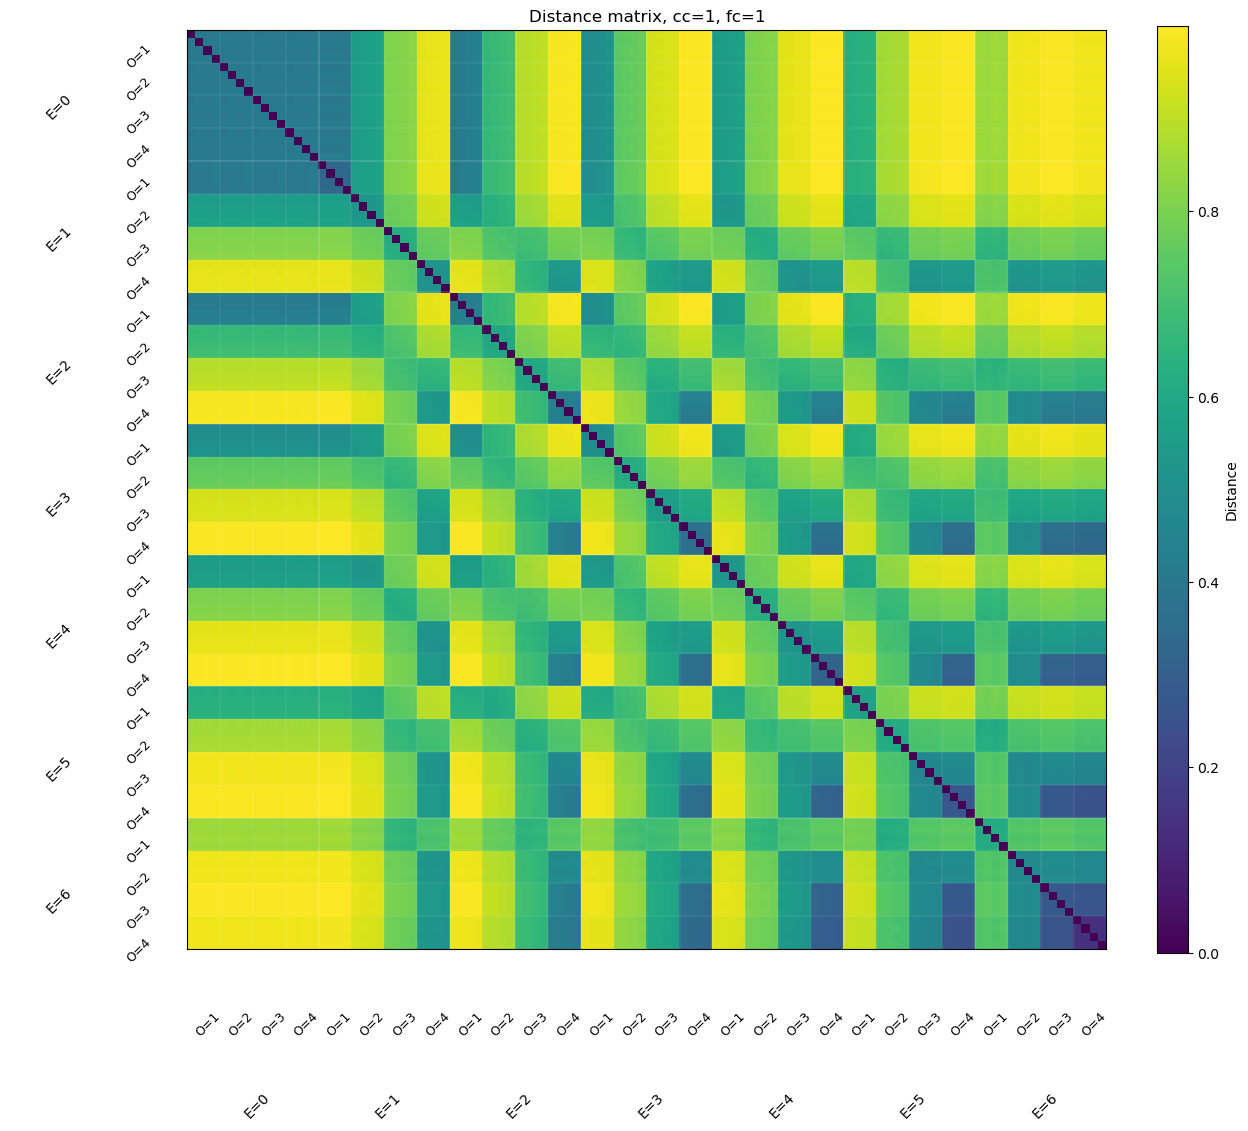

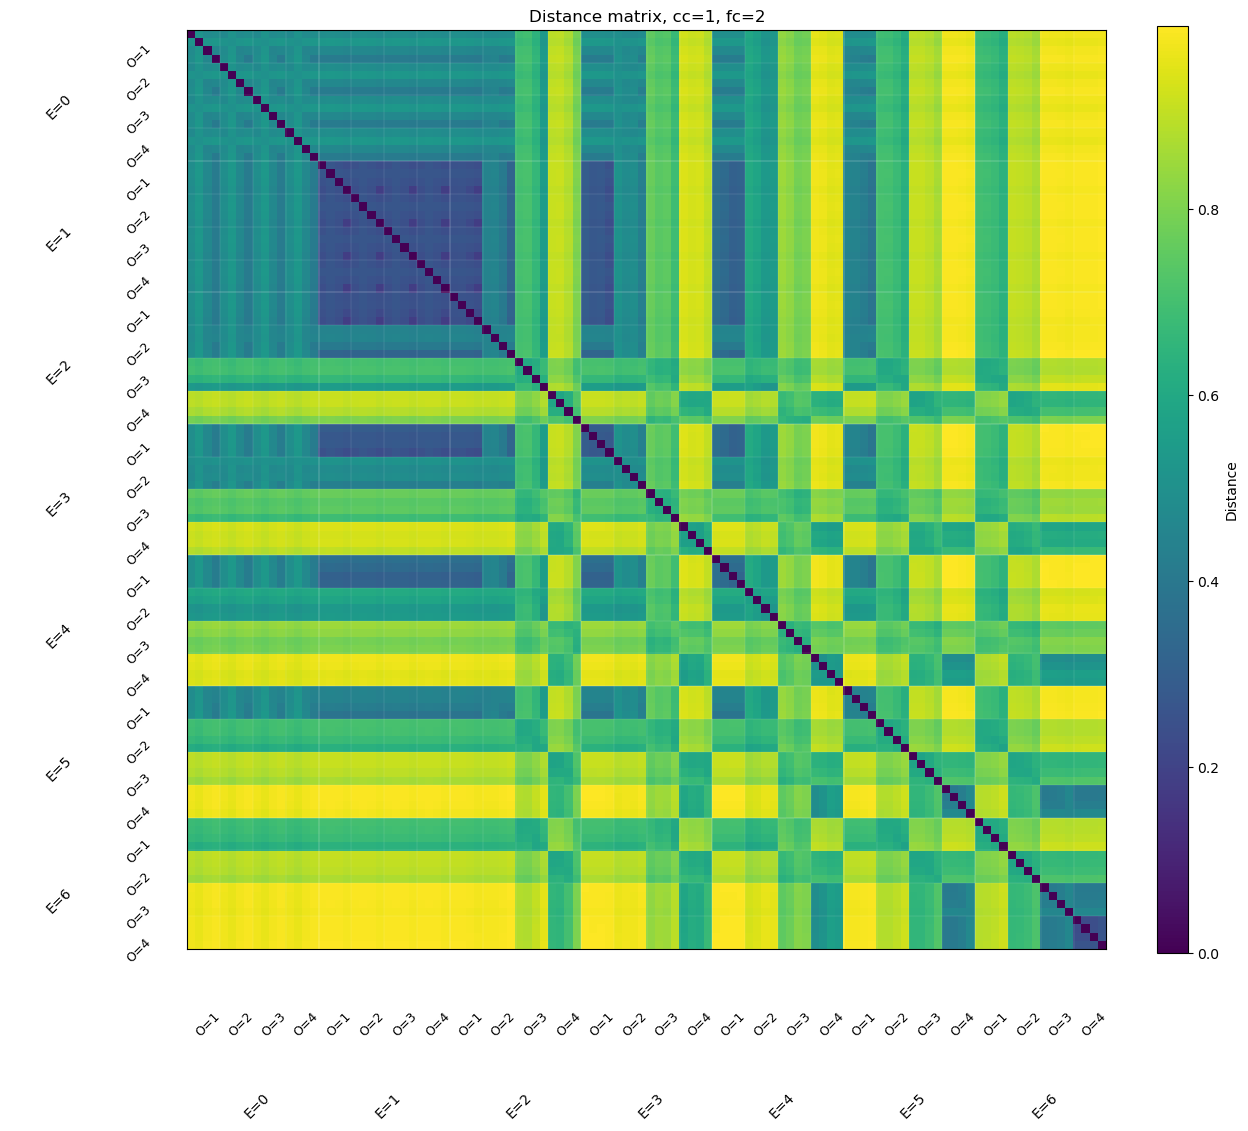

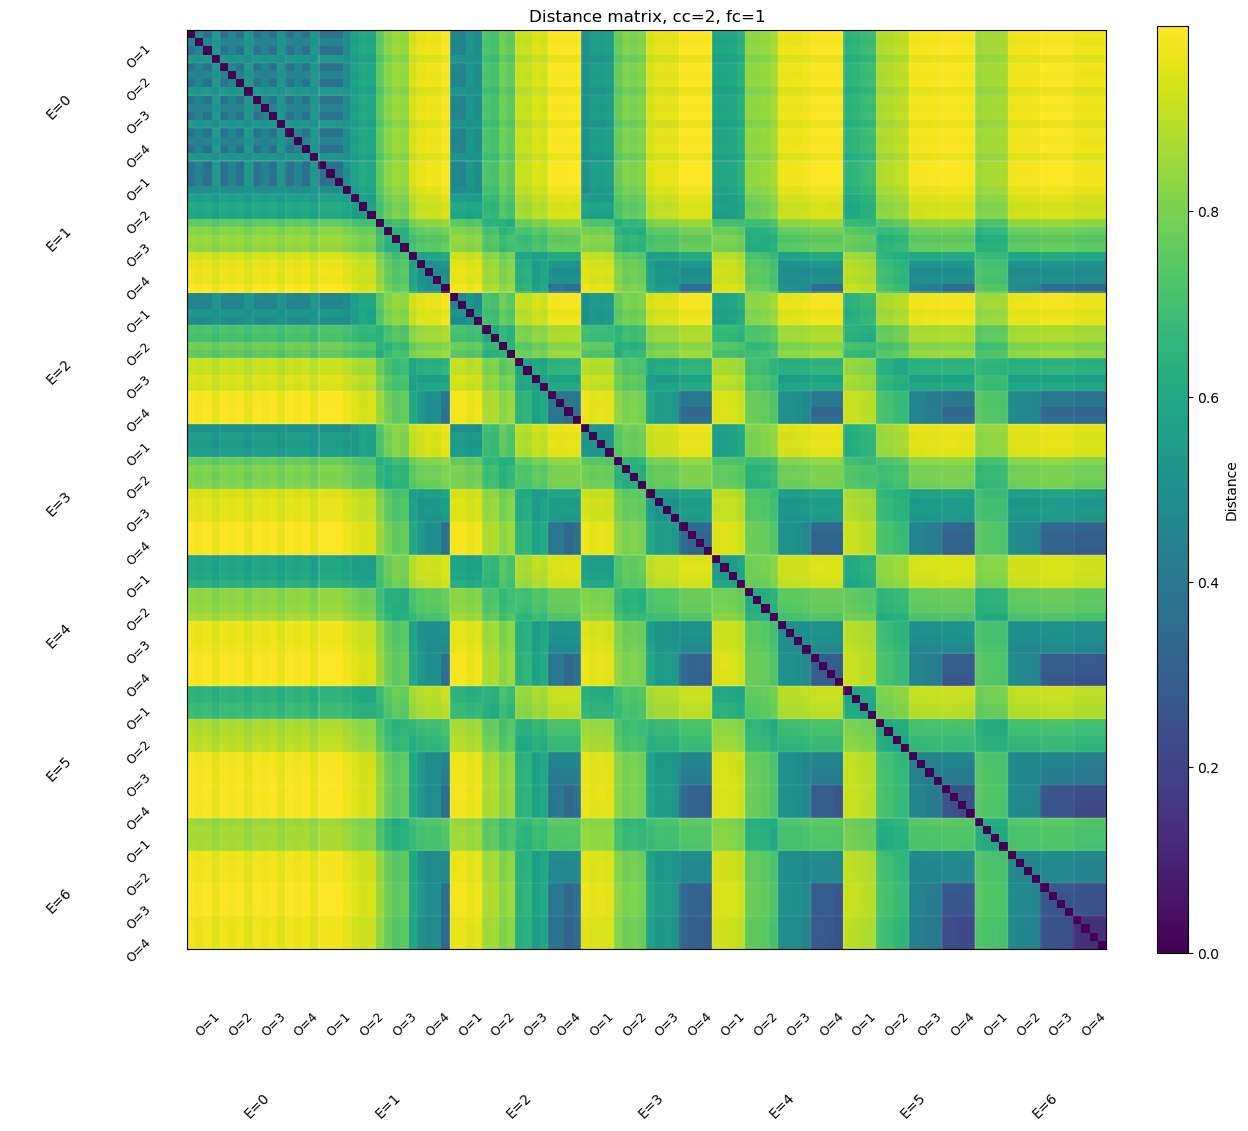

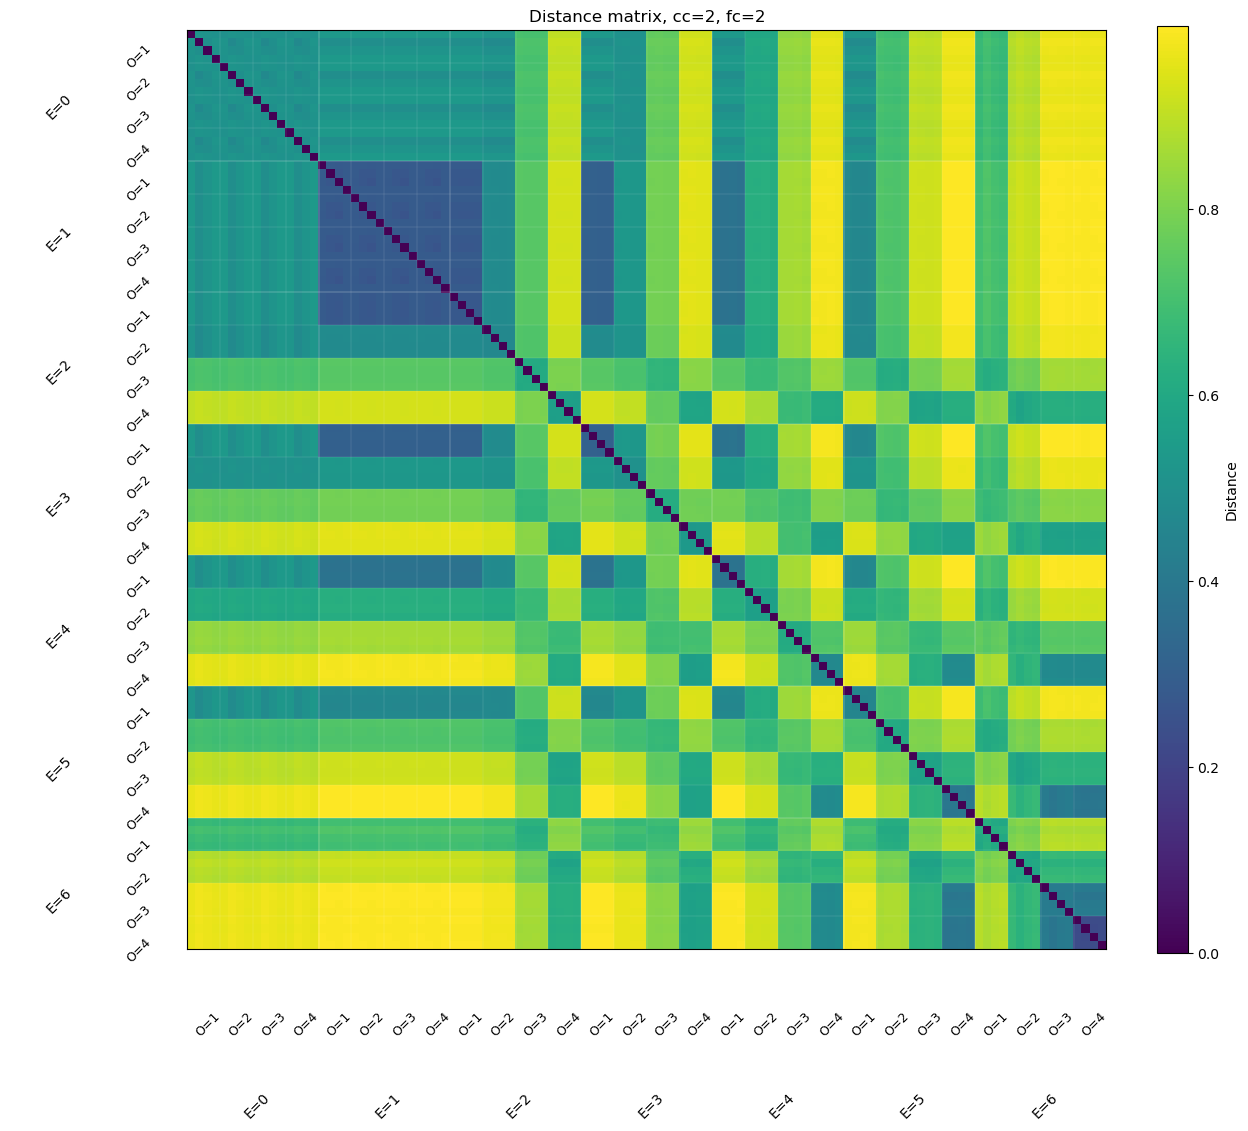

  0%|          | 160/100000 [00:00<00:02, 40470.91it/s]


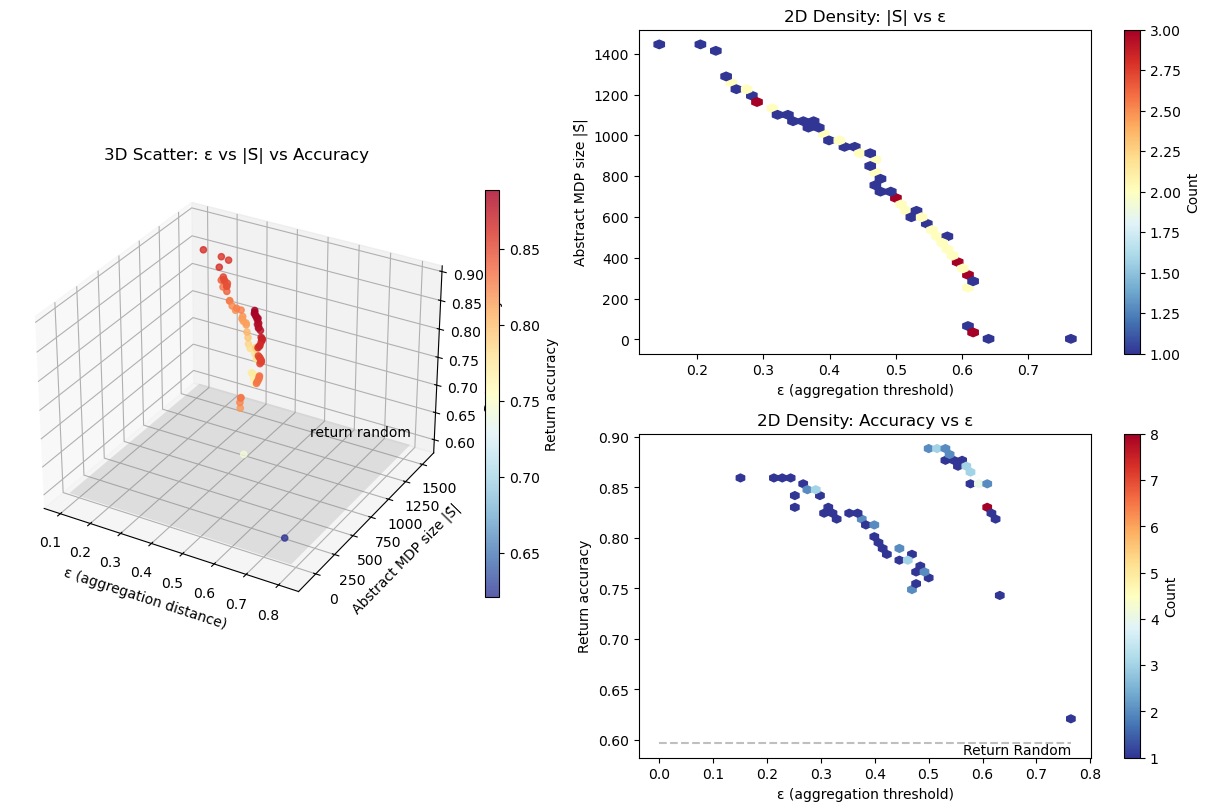

In [2]:
# Create the task and its parameters (transition probability, reward...):
task = LimitedEnergyTask(O=[1, 2, 3, 4], p_offer=[1/4] * 4)
task.build()

# Create full MDP and compute solution for later reference:
gamma = 0.99
task_mdp = MDP(task.states, task.tp, task.r, gamma, s2i=task.s2i)
V_full, Q_full = task_mdp.value_iteration()
R_full = task_mdp.expected_return(task_mdp.greedy_policy(Q_full), initial_energy=3)
# Compute pairwise distances:
distances_matrix = task_mdp.entropy_weighting(Q_full)

# Plot the distance matrix
for ctrans in [[1, 1], [1, 2], [2, 1], [2, 2]]:
    # Extract only to t=4, as we don't quite care about anything beyond that:
    distances_matrix_reduced = np.zeros([len(task.O) * len(task.E) * 4 * 2, len(task.O) * len(task.E) * 4 * 2])
    states_reduced = []
    ctr1 = 0
    for i, state1 in enumerate(task_mdp.states):
        if state1[-1] > 4:
            continue
        if state1[-2] == ctrans[0] and state1[-3] == ctrans[1]:
            states_reduced.append(state1)
            ctr2 = 0
            for state2 in task_mdp.states:
                if state2[-1] > 4:
                    continue
                if state2[-2] == ctrans[0] and state2[-3] == ctrans[1]:
                    distances_matrix_reduced[ctr1, ctr2] = distances_matrix[task_mdp.s2i[state1], task_mdp.s2i[state2]]
                    ctr2 += 1
            ctr1 += 1
    fig = plot_state_matrix(distances_matrix_reduced, states_reduced, feature_names=["E", "O", "CC", "FC", "T"], depth=2, title=f"Distance matrix, cc={ctrans[0]}, fc={ctrans[1]}")
    plt.show()


# Get return from ground MDP with random policy to use as floor
R_random_relative = 1 - (R_full - task_mdp.expected_return(np.zeros((len(task_mdp.states), 2)) + 0.5, initial_energy=3))/R_full
# Get the unique abstraction distances:
unique_dist = np.unique(np.round(distances_matrix, decimals=3))
# Prepare lists:
abstraction_distance, abstraction_size, abstraction_return_accuracy = [], [], []
variables_names = ["energy", "offers", "current cost", "future cost", "t"]

# Loop through every 10 distances:
n_states = len(task_mdp.states)
for eps in unique_dist: #unique_dist:
    # Generate abstracted MDP at that level of abstraction:
    abstract_mdp, state_classes, class_of_state = task_mdp.distance_reduce_mdp(eps+0.0001, distance_matrix=distances_matrix)
    # Solve the MDP:
    V_R, Q_R = abstract_mdp.value_iteration()
    # Print the summary:
    if n_states - len(abstract_mdp.states) < 10:
        continue
    else:
        n_states = len(abstract_mdp.states)

    # Project back to Ground space:
    V_from_abstract, Q_from_abstract = abstract2ground_value(class_of_state, V_R, Q_R)
    # Compute the expected return:
    abstraction_return_accuracy.append(1 - (R_full - task_mdp.expected_return(task_mdp.soft_policy(Q_from_abstract), initial_energy=3))/R_full)
    abstraction_distance.append(eps)
    abstraction_size.append(len(state_classes))

# Convert to numpy arrays:
abstraction_size = np.array(abstraction_size)
abstraction_distance = np.array(abstraction_distance)
abstraction_return_accuracy = np.array(abstraction_return_accuracy)# Layout: 3D on the left spanning rows, two hexbin plots on the right
fig, axes = plt.subplot_mosaic(
    [
        ["three_d", "hex_size"],
        ["three_d", "hex_acc"],
    ],
    figsize=(12, 8),
    constrained_layout=True,   # handles spacing nicely
)

# ---- Turn the left axis into a 3D axis
ax2d = axes["three_d"]
sspec = ax2d.get_subplotspec()
ax2d.remove()
ax3d = fig.add_subplot(sspec, projection="3d")

# 3D scatter: ε vs |S̄| vs accuracy
sc = ax3d.scatter(
    abstraction_distance,
    abstraction_size,
    abstraction_return_accuracy,
    c=abstraction_return_accuracy,
    alpha=0.8,
    cmap='RdYlBu_r'
)
# Add chance return:
x_min, x_max = ax3d.get_xlim()
y_min, y_max = ax3d.get_ylim()
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 10),
    np.linspace(y_min, y_max, 10)
)
zz = np.full_like(xx, R_random_relative)
ax3d.plot_surface(
    xx, yy, zz,
    alpha=0.2,
    linewidth=0,
    shade=False,
    color='grey'
)
x_mid = 0.5 * (x_min + x_max)
y_mid = 0.5 * (y_min + y_max)
ax3d.text(
    x_max,
    y_max,
    R_random_relative + 0.01,     # small offset above the plane
    "return random",
    ha='right',
    va='bottom'
)
ax3d.set_xlabel("ε (aggregation distance)")
ax3d.set_ylabel("Abstract MDP size |S̄|")
ax3d.set_zlabel("Return accuracy")
ax3d.set_title("3D Scatter: ε vs |S̄| vs Accuracy")

# small, slim colorbar for the 3D plot
fig.colorbar(
    sc,
    ax=ax3d,
    label="Return accuracy",
    pad=0.05,
    fraction=0.03,   # overall size
    aspect=30,       # thin bar
)

# ---- Upper-right hexbin: ε vs |S̄|
ax1 = axes["hex_size"]
hb1 = ax1.hexbin(
    abstraction_distance,
    abstraction_size,
    gridsize=40,
    mincnt=1,
    cmap="RdYlBu_r",
)
ax1.set_xlabel("ε (aggregation threshold)")
ax1.set_ylabel("Abstract MDP size |S̄|")
ax1.set_title("2D Density: |S̄| vs ε")
fig.colorbar(hb1, ax=ax1, label="Count")

# ---- Lower-right hexbin: ε vs accuracy
ax2 = axes["hex_acc"]
hb2 = ax2.hexbin(
    abstraction_distance,
    abstraction_return_accuracy,
    gridsize=40,
    mincnt=1,
    cmap="RdYlBu_r",
)
ax2.hlines(y=R_random_relative, xmin=0, xmax=np.max(abstraction_distance), linestyle='--', color='grey', alpha=0.5)
ax2.text(np.max(abstraction_distance), R_random_relative, 'Return Random', ha='right', va='top')
ax2.set_xlabel("ε (aggregation threshold)")
ax2.set_ylabel("Return accuracy")
ax2.set_title("2D Density: Accuracy vs ε")
fig.colorbar(hb2, ax=ax2, label="Count")

plt.show()


# Plot the decision values of various abstraction distances and the aggregated classes

<>:1: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
<>:10: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
<>:1: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
<>:10: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
/tmp/ipykernel_261628/3551067838.py:1: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
  fig, ax = task_mdp.plot_dv(Q_full[:, 1]-Q_full[:, 0], title=f'Decision value at $\epsilon={0}$', tmax=4, cmap_midpoint=0)
/tmp/ipykernel_261628/3551067838.py:10: SyntaxWarning: "\e" is an invalid es

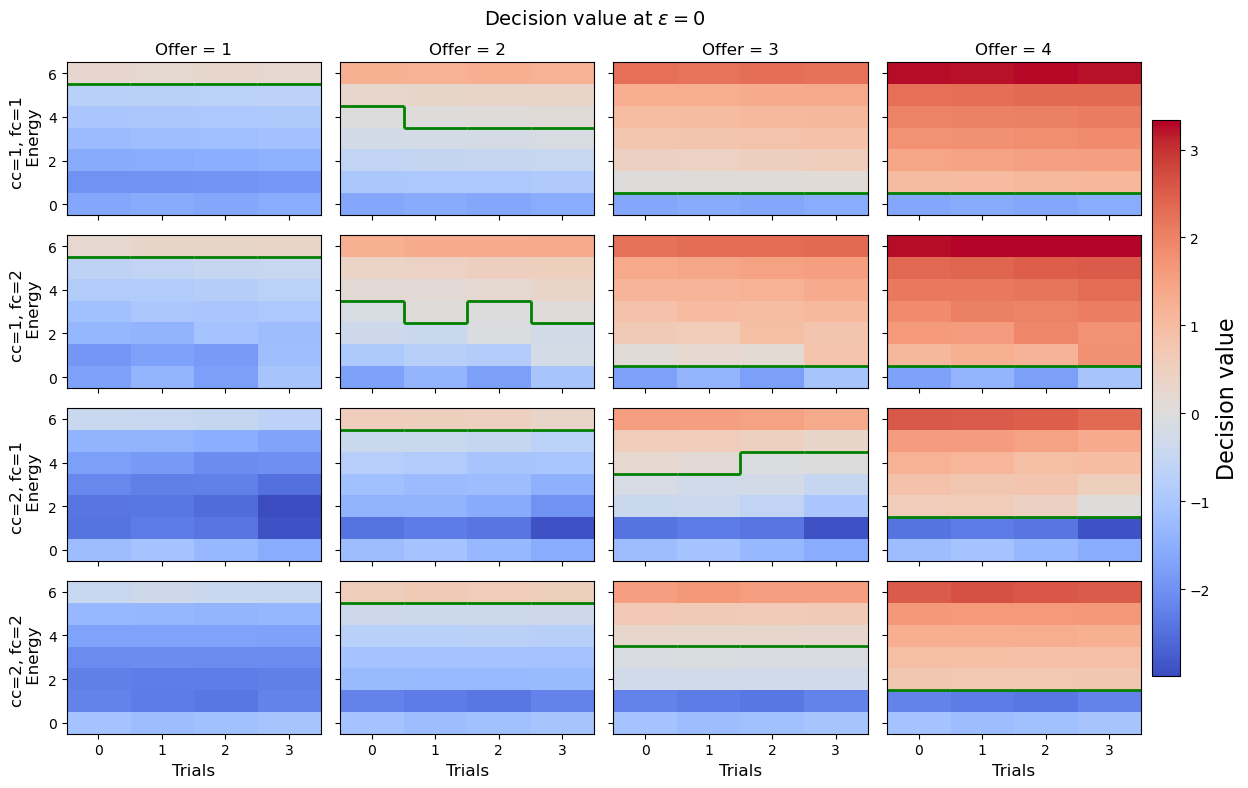

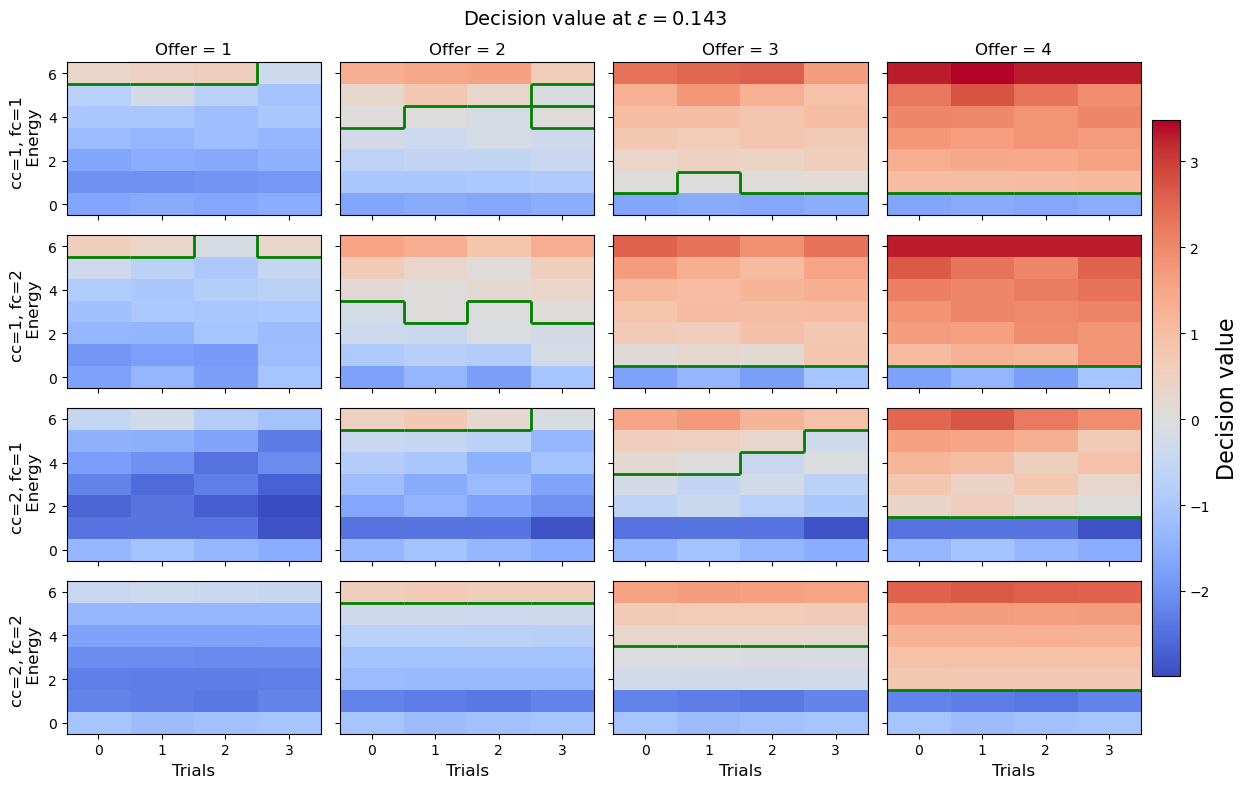

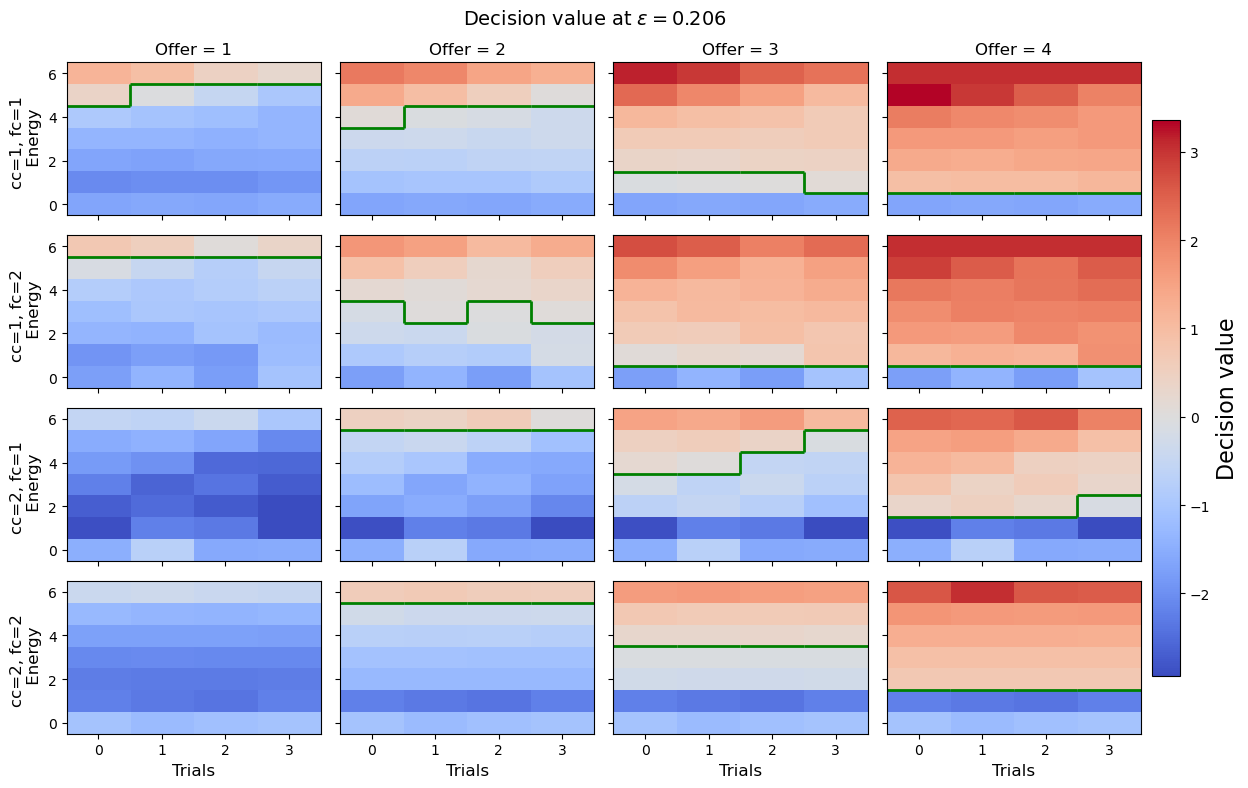

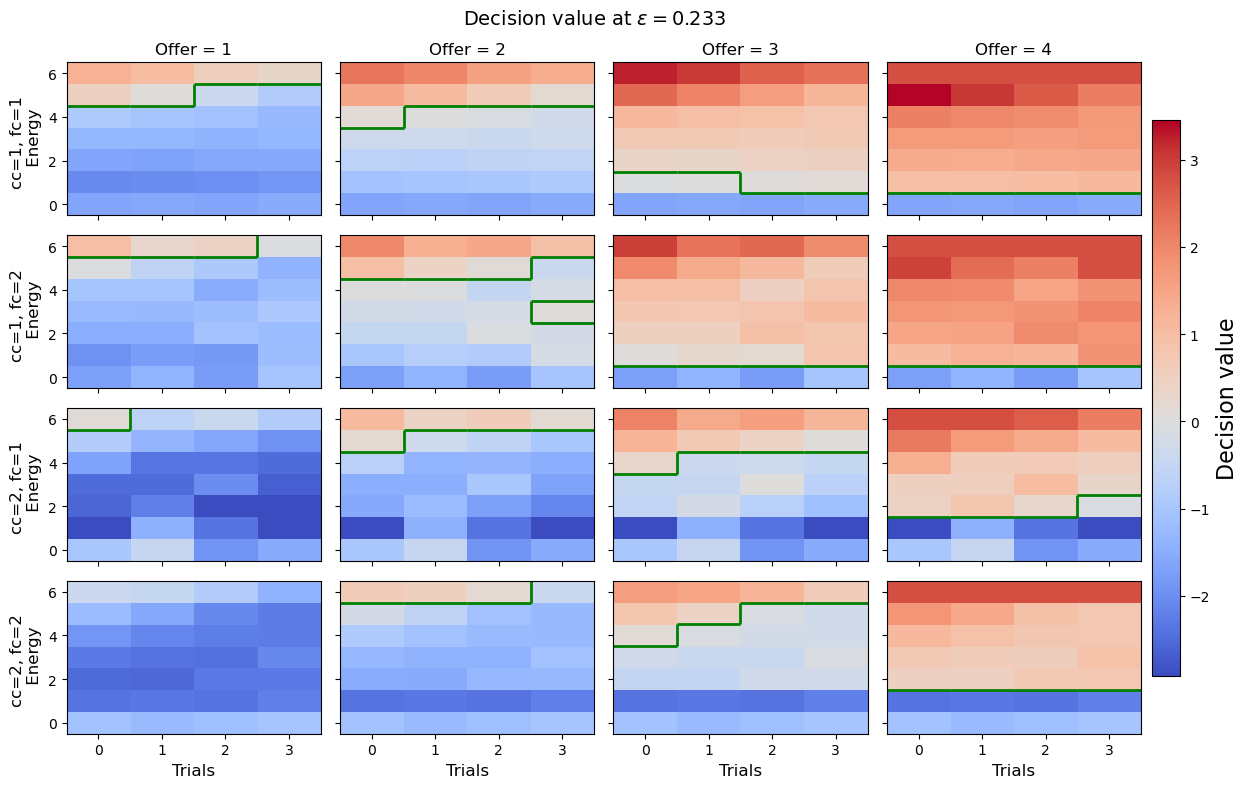

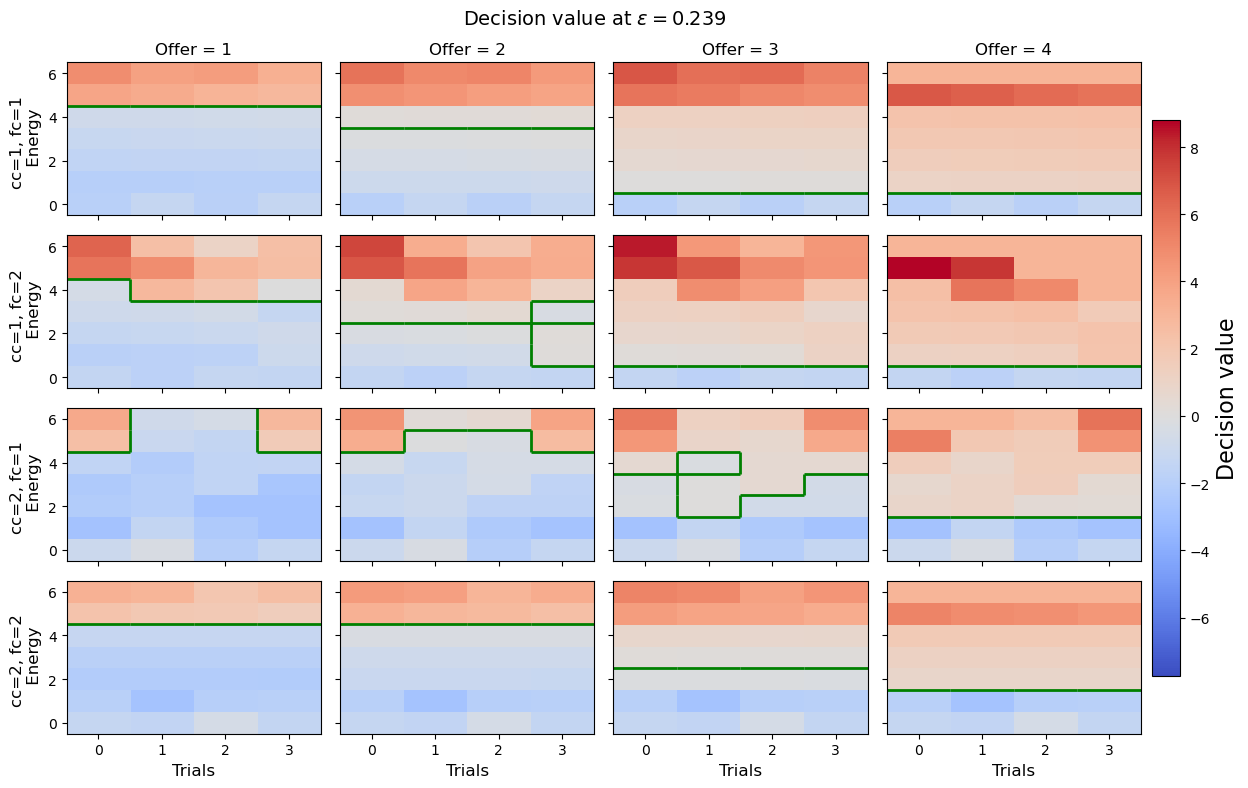

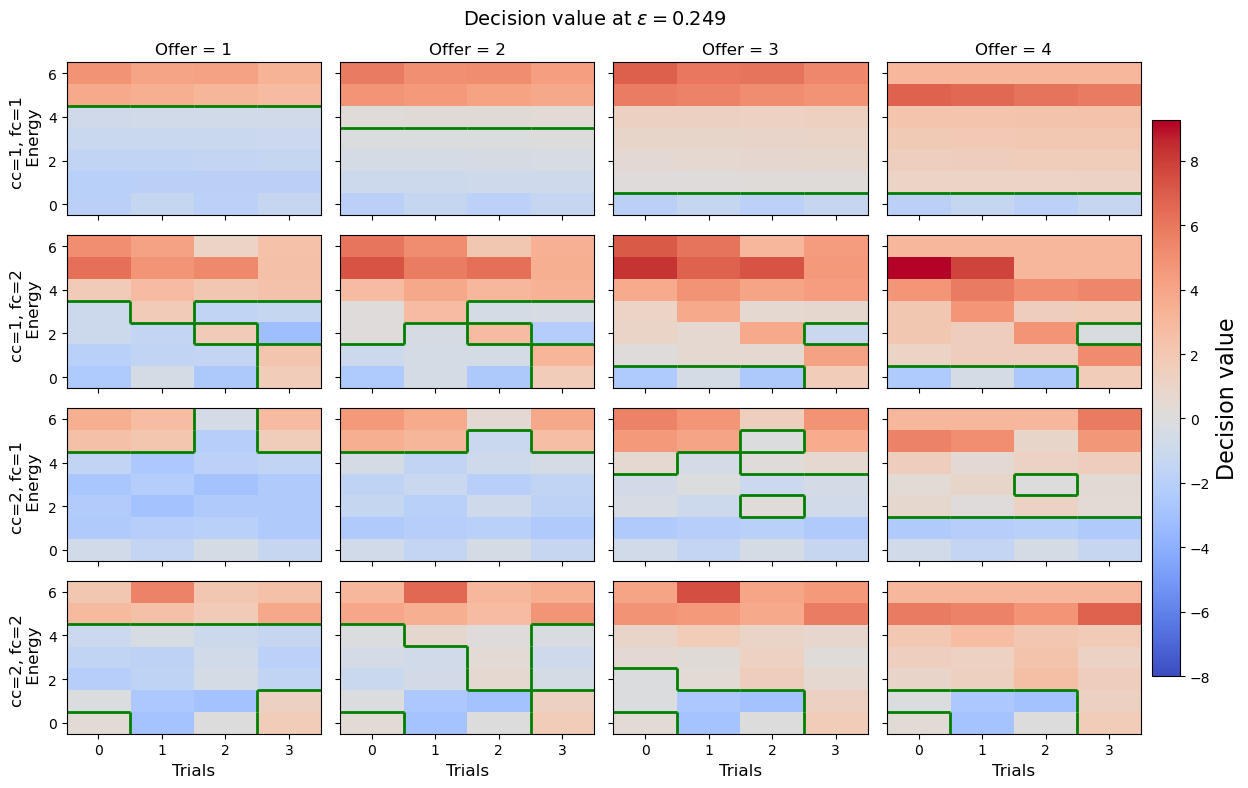

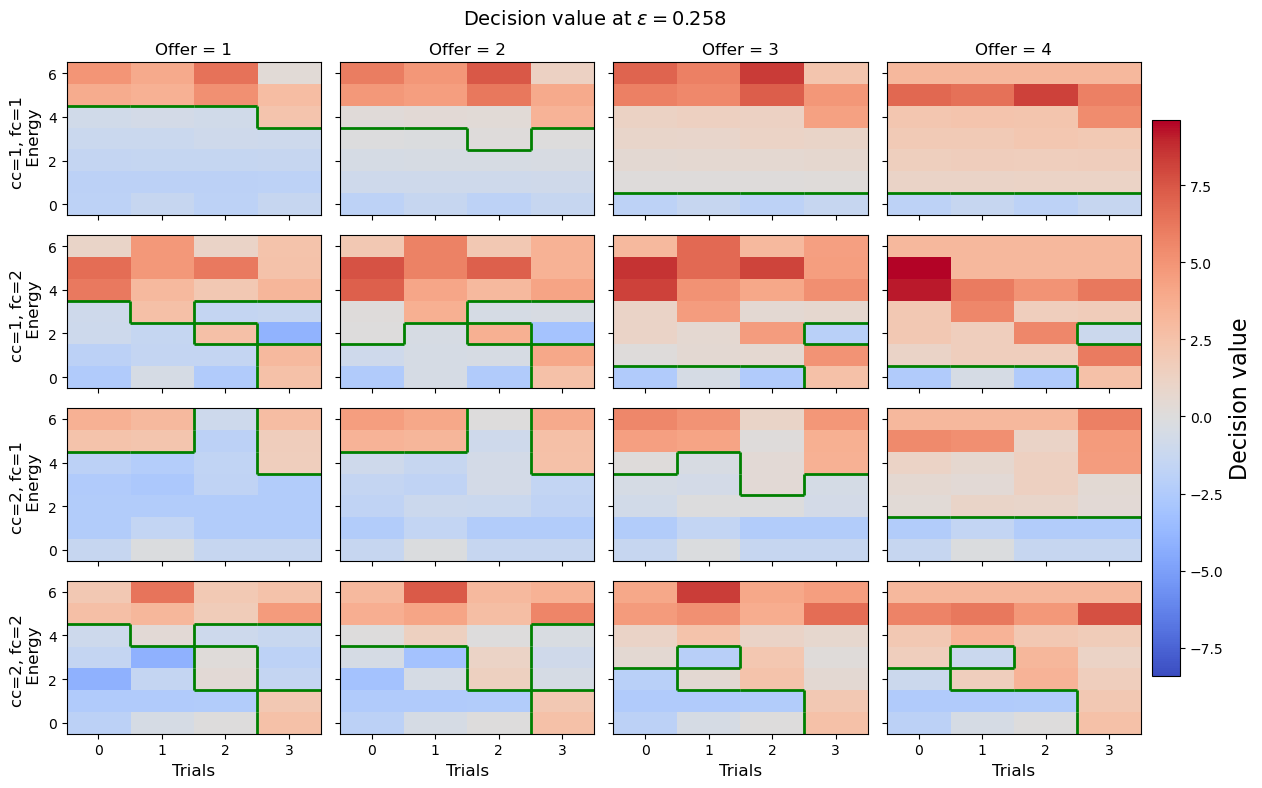

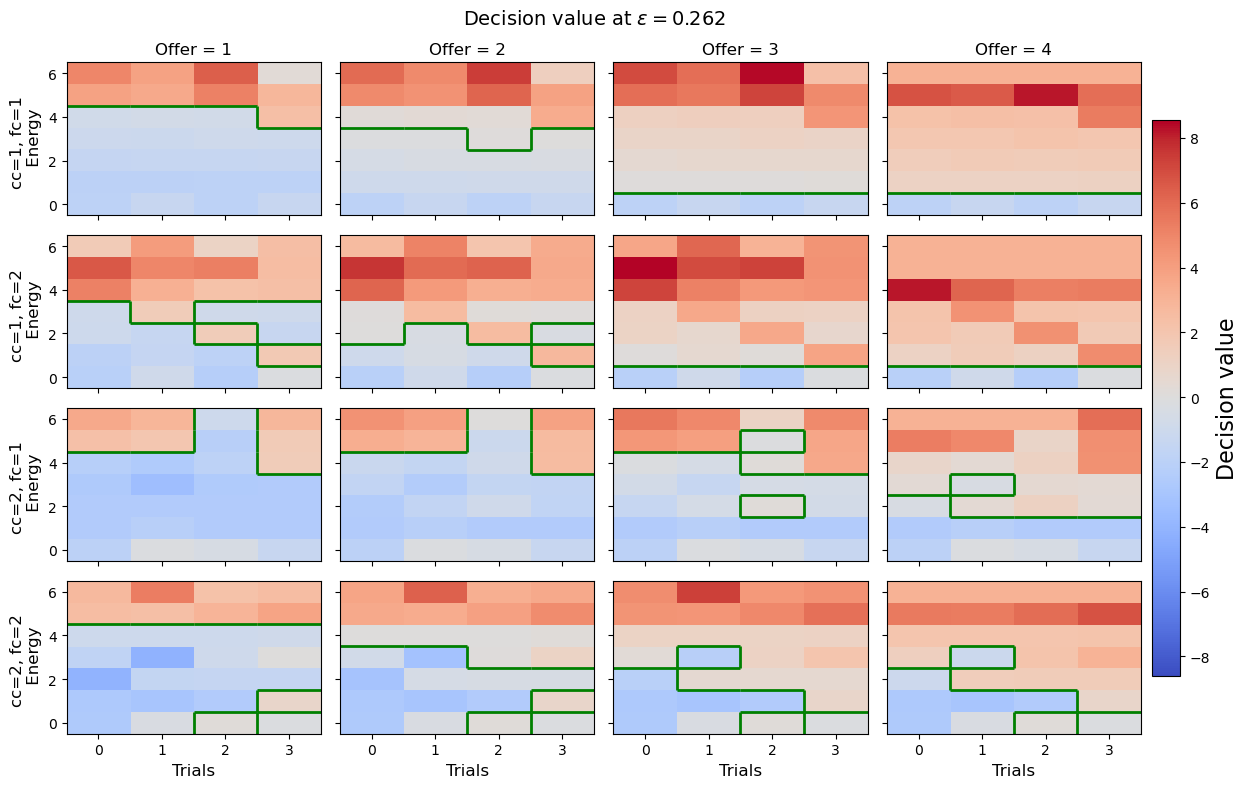

In [3]:
fig, ax = task_mdp.plot_dv(Q_full[:, 1]-Q_full[:, 0], title=f'Decision value at $\epsilon={0}$', tmax=4, cmap_midpoint=0)
controllers = []
for eps in abstraction_distance[0:7]:
    # Generate abstracted MDPs:
    abstract_mdp, state_classes, class_of_state = task_mdp.distance_reduce_mdp(eps + 0.0001, distance_matrix=distances_matrix)
    # Solve the MDP:
    V_R, Q_R = abstract_mdp.value_iteration()
    # Project back to ground space:
    V_from_abstract, Q_from_abstract = abstract2ground_value(class_of_state, V_R, Q_R)
    fig, ax = task_mdp.plot_dv(Q_from_abstract[:, 1]-Q_from_abstract[:, 0], title=f'Decision value at $\epsilon={eps}$', tmax=4, cmap_midpoint=0)
    controllers.append(add_state_class_highlighting_with_summary(fig, ax, offers=task.O, 
                                                                           current_costs=task.C, 
                                                                           future_costs=task.C,
                                                                           energy_vals=task.E,
                                                                           tmax=task.tmax,
                                                                           state_classes=state_classes))
plt.show()

# Fit the abstractions to the data:

In [4]:
unique_dist = np.unique(np.round(distances_matrix, decimals=3))
n_states = len(task_mdp.states)
DVs = []

# Loop through each trial to set DV:
dv = Q_full[:, 1] - Q_full[:, 0]
dv_trials = []
mdl_sim_resps = []
decision_match = []
for trial_i, trial in data.iterrows():
    e, o, cc, t = trial.energy, trial.reward, trial.energy_cost, trial.trial
    fc = transitions_costs[trial.transition][1]
    dv_trials.append(dv[task.s2i[(e, o, cc, fc, t)]])
    # Simulate data according to that plan:
    mdl_sim_resps.append(np.random.binomial(1, expit(dv[task.s2i[(e, o, cc, fc, t)]])))
    decision_match.append(1 - np.abs(trial.response - mdl_sim_resps[-1]))
data[f'DV-eps: {0.0}'] = dv_trials

for eps in abstraction_distance[0:7]: #unique_dist:
    # Generate abstracted MDP at that level of abstraction:
    abstract_mdp, state_classes, class_of_state = task_mdp.distance_reduce_mdp(eps, distance_matrix=distances_matrix)
    # Solve the MDP:
    V_R, Q_R = abstract_mdp.value_iteration()
    # Project back to Ground space:
    V_from_abstract, Q_from_abstract = abstract2ground_value(class_of_state, V_R, Q_R)
    # Add to decision 
    dv = Q_from_abstract[:, 1] - Q_from_abstract[:, 0]
    # Loop through each trial to set DV:
    dv_trials = []
    mdl_sim_resps = []
    decision_match = []
    for trial_i, trial in data.iterrows():
        e, o, cc, t = trial.energy, trial.reward, trial.energy_cost, trial.trial
        fc = transitions_costs[trial.transition][1]
        dv_trials.append(dv[task.s2i[(e, o, cc, fc, t)]])
        # Simulate data according to that plan:
        mdl_sim_resps.append(np.random.binomial(1, expit(dv[task.s2i[(e, o, cc, fc, t)]])))
        decision_match.append(1 - np.abs(trial.response - mdl_sim_resps[-1]))
    data[f'DV-eps: {eps}'] = dv_trials


  0%|          | 63/100000 [00:00<15:44, 105.78it/s]


## Model:

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta_pop, sigma_pop, z]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 35 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta_pop, sigma_pop, z]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 35 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta_pop, sigma_pop, z]


...

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 43 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta_pop, sigma_pop, z]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 44 seconds.
There were 1000 divergences after tuning. Increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta_pop, sigma_pop, z]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 47 seconds.
/home/alex-lepauvre/miniforge3/envs/pymc_env/lib/python3.14/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


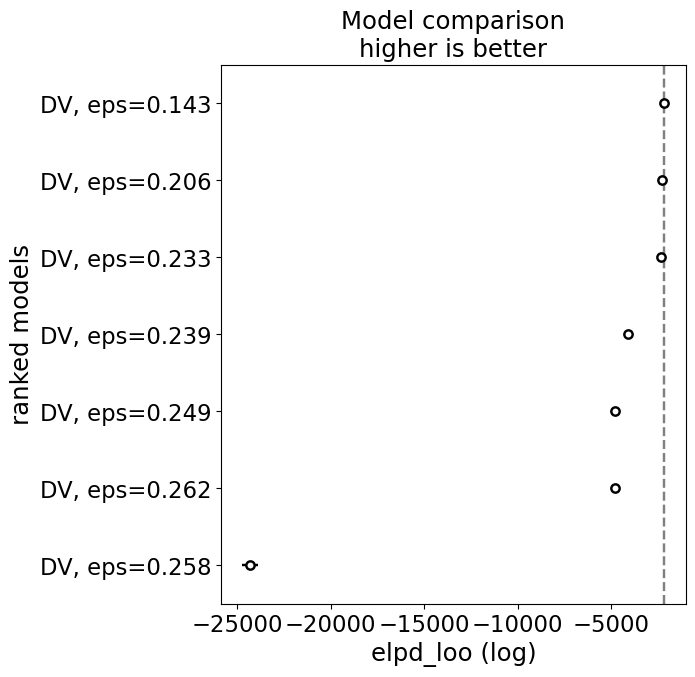

In [5]:
# Extract the data of one subject:
subj_idx_raw, subj_labels = pd.factorize(data["vpn"])
coords = {
    "subject": subj_labels,
    "coef": ["intercept", "slope"],
}
traces = {}
for eps_i, eps in enumerate(abstraction_distance[0:7]):
    # Fit the model:
    _, traces[f'DV, eps={eps}'] = hierarchical_binomial_regression(data["response"],
                                                  data[f"DV-eps: {eps}"],
                                                  subj_idx_raw,
                                                  coords)
    data[f'p(y=1|y_obs)@eps={eps}'] = traces[f'DV, eps={eps}'].posterior.p.mean(dim=["chain", "draw"])

# Compare models:
model_comparison = az.compare(traces)
az.plot_compare(model_comparison);